In [10]:
"""Perform L1"""

'Perform L1'

In [1]:
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter, gaussian_filter1d

%load_ext autoreload
%autoreload 2

from common.utils import step_func_gen
from deblurring.blurring import blur_and_noise
from deblurring.sparsity import signal_l1
from solvers.proximal import ADMMSolverTV, ISTASolver

In [118]:
"""Create toy sparse function and add noise"""

x, f = step_func_gen(500)
f = np.diff(f, prepend=0)

theta = 0.1 * np.std(f)  # 2% noise
sigma = 2.0
kernel = partial(gaussian_filter1d, sigma=sigma)
g = blur_and_noise(f, kernel, theta)

[WARNING] 2025-03-25 19:03:16 | Did not converge | solvers.proximal-solve:178


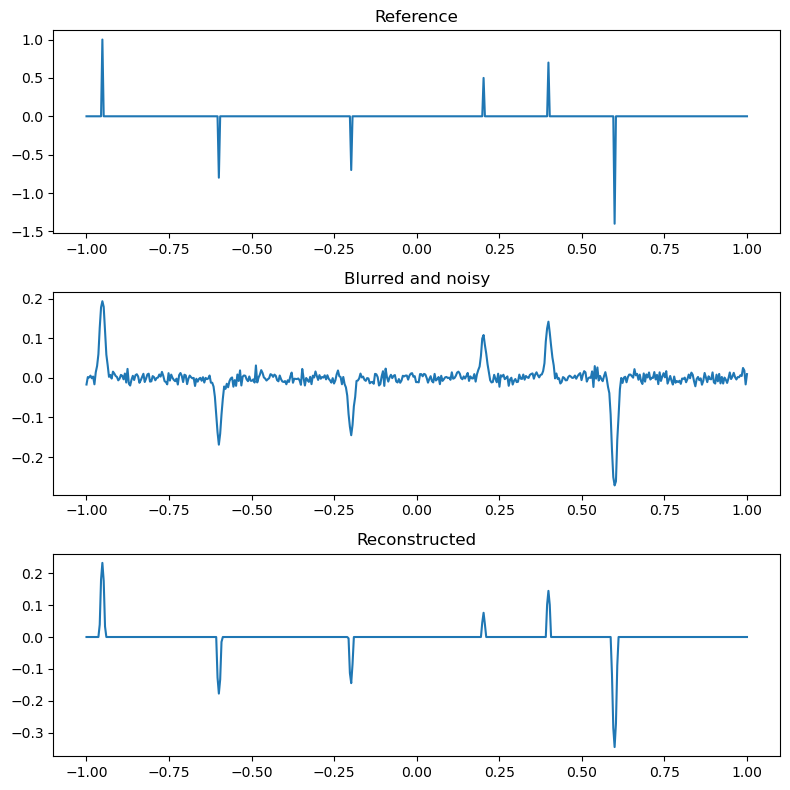

In [121]:
"""Solve using ISTA and L1 regularisation"""

solver = ISTASolver(g, kernel)
f_hat = solver.solve(shrinkage_func=signal_l1, params={"lambda": 0.1, "quantile": 0.95})

plt.figure(figsize=(8, 8))
plt.subplot(3, 1, 1)
plt.plot(x, f)
plt.title("Reference")
plt.subplot(3, 1, 2)
plt.plot(x, g)
plt.title("Blurred and noisy")
plt.subplot(3, 1, 3)
plt.title("Reconstructed")
plt.plot(x, f_hat)
plt.tight_layout()
plt.show()

In [141]:
"""Create toy sparse function and add noise"""

x, f = step_func_gen(500)

theta = 0.1 * np.std(f)  # 2% noise
sigma = 2.0
kernel = partial(gaussian_filter1d, sigma=sigma)
g = blur_and_noise(f, kernel, theta)

[INFO] 2025-03-25 20:39:25 | Converged in 85 iterations | solvers.proximal-solve:321


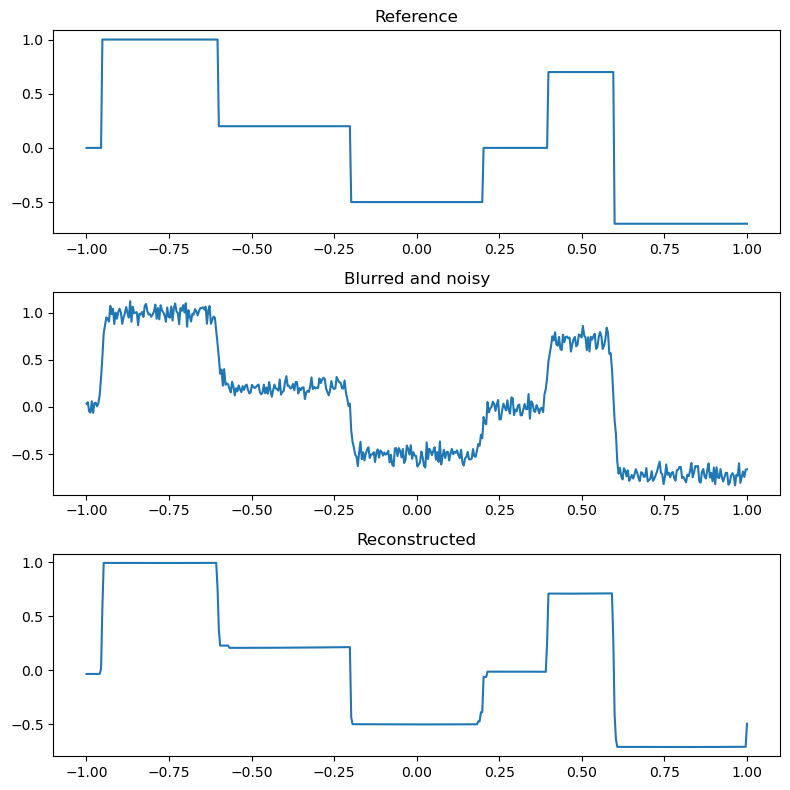

In [ ]:
"""Solve using total variation regularisation"""

solver = ADMMSolverTV(g, kernel)
f_hat = solver.solve(
    shrinkage_func=signal_l1,
    # params={"threshold": 0.05, "rho": 0.1},
    params={"threshold": 0.4, "rho": 10.},
)

plt.figure(figsize=(8, 8))
plt.subplot(3, 1, 1)
plt.plot(x, f)
plt.title("Reference")
plt.subplot(3, 1, 2)
plt.plot(x, g)
plt.title("Blurred and noisy")
plt.subplot(3, 1, 3)
plt.title("Reconstructed")
plt.plot(x, f_hat)
plt.tight_layout()
plt.show()

In [50]:
"""Read image and blur with added noise"""

f = plt.imread("../../data/Cameraman256.png")
f = (f - f.min()) / (f.max() - f.min())

theta = 0.2 * np.std(f)  # 20% noise

g = blur_and_noise(f, lambda x: x, theta)

In [ ]:
"""Solve using ISTA and L1 regularisation"""

solver = ISTASolver(g, kernel)

plt.figure(figsize=(8, 6))
plt.subplot(2, 3, 1)
plt.imshow(f, cmap="gray")
plt.axis("off")
plt.title("Reference")
plt.subplot(2, 3, 2)
plt.imshow(g, cmap="gray")
plt.axis("off")
plt.title("Blurred and noisy")

for idx, quantile in enumerate([0.0, 0.1, 0.5, 0.9]):
    f_hat = solver.solve(
        shrinkage_func=signal_l1,
        params={"quantile": quantile, "lambda": 0.1},
    )
    plt.subplot(2, 3, 3 + idx)
    plt.title(f"Reconstructed: q={quantile}")
    plt.imshow(f_hat, cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

[WARNING] 2025-03-25 10:21:41 | Did not converge | solvers.proximal-solve:319
[WARNING] 2025-03-25 10:21:50 | Did not converge | solvers.proximal-solve:319
[WARNING] 2025-03-25 10:22:00 | Did not converge | solvers.proximal-solve:319
[WARNING] 2025-03-25 10:22:09 | Did not converge | solvers.proximal-solve:319


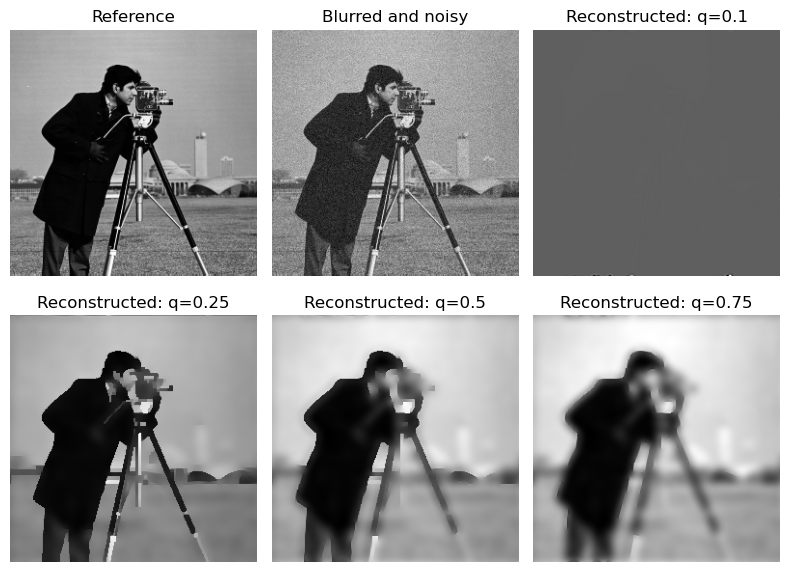

In [51]:
"""Solve using total variation regularisation - tune lambda"""

solver = ADMMSolverTV(g, kernel)

plt.figure(figsize=(8, 6))
plt.subplot(2, 3, 1)
plt.imshow(f, cmap="gray")
plt.axis("off")
plt.title("Reference")
plt.subplot(2, 3, 2)
plt.imshow(g, cmap="gray")
plt.axis("off")
plt.title("Blurred and noisy")

for idx, thresh in enumerate([0.1, 0.25, 0.5, 0.75]):
    f_hat = solver.solve(
        shrinkage_func=signal_l1,
        params={"threshold": thresh, "rho": 0.5},
        max_iter=20,
    )
    plt.subplot(2, 3, 3 + idx)
    plt.title(f"Reconstructed: q={thresh}")
    plt.imshow(f_hat, cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [52]:
"""Read image and blur with added noise"""

f = plt.imread("../../data/Cameraman256.png")
f = (f - f.min()) / (f.max() - f.min())

theta = 0.02 * np.std(f)  # 2% noise
sigma = 1.0
kernel = partial(gaussian_filter, sigma=sigma)
g = blur_and_noise(f, kernel, theta)

ValueError: operands could not be broadcast together with shapes (256,256) (65536,) 

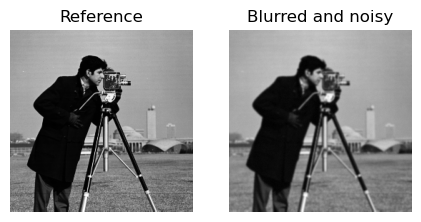

In [4]:
"""Solve using ISTA and L1 regularisation"""

solver = ISTASolver(g, kernel)

plt.figure(figsize=(8, 6))
plt.subplot(2, 3, 1)
plt.imshow(f, cmap="gray")
plt.axis("off")
plt.title("Reference")
plt.subplot(2, 3, 2)
plt.imshow(g, cmap="gray")
plt.axis("off")
plt.title("Blurred and noisy")

for idx, quantile in enumerate([0.0, 0.1, 0.5, 0.9]):
    f_hat = solver.solve(
        shrinkage_func=signal_l1,
        params={"quantile": quantile, "lambda": 0.1},
    )
    plt.subplot(2, 3, 3 + idx)
    plt.title(f"Reconstructed: q={quantile}")
    plt.imshow(f_hat, cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

[WARNING] 2025-03-25 09:11:43 | Did not converge | solvers.proximal-solve:319
[WARNING] 2025-03-25 09:11:50 | Did not converge | solvers.proximal-solve:319
[WARNING] 2025-03-25 09:11:57 | Did not converge | solvers.proximal-solve:319
[WARNING] 2025-03-25 09:11:59 | x-update did not converge | solvers.proximal-solve:307
[WARNING] 2025-03-25 09:11:59 | x-update did not converge | solvers.proximal-solve:307
[WARNING] 2025-03-25 09:11:59 | x-update did not converge | solvers.proximal-solve:307
[WARNING] 2025-03-25 09:11:59 | x-update did not converge | solvers.proximal-solve:307
[WARNING] 2025-03-25 09:12:01 | Did not converge | solvers.proximal-solve:319


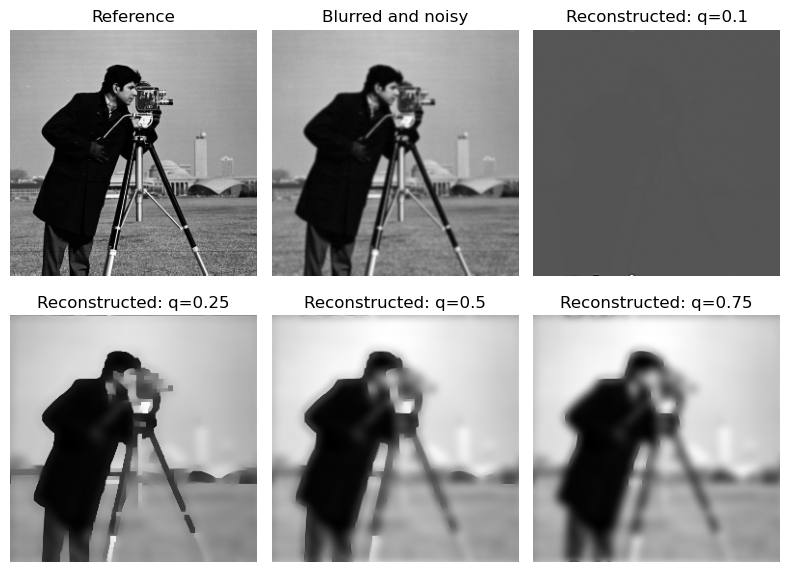

In [53]:
"""Solve using total variation regularisation - tune lambda"""

solver = ADMMSolverTV(g, kernel)

plt.figure(figsize=(8, 6))
plt.subplot(2, 3, 1)
plt.imshow(f, cmap="gray")
plt.axis("off")
plt.title("Reference")
plt.subplot(2, 3, 2)
plt.imshow(g, cmap="gray")
plt.axis("off")
plt.title("Blurred and noisy")

for idx, thresh in enumerate([0.1, 0.25, 0.5, 0.75]):
    f_hat = solver.solve(
        shrinkage_func=signal_l1,
        params={"threshold": thresh, "rho": 0.5},
        max_iter=20,
    )
    plt.subplot(2, 3, 3 + idx)
    plt.title(f"Reconstructed: q={thresh}")
    plt.imshow(f_hat, cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

[WARNING] 2025-03-25 09:20:00 | Did not converge | solvers.proximal-solve:319
[WARNING] 2025-03-25 09:20:06 | x-update did not converge | solvers.proximal-solve:307
[WARNING] 2025-03-25 09:20:07 | x-update did not converge | solvers.proximal-solve:307
[WARNING] 2025-03-25 09:20:09 | Did not converge | solvers.proximal-solve:319
[WARNING] 2025-03-25 09:20:17 | Did not converge | solvers.proximal-solve:319
[WARNING] 2025-03-25 09:21:29 | Did not converge | solvers.proximal-solve:319


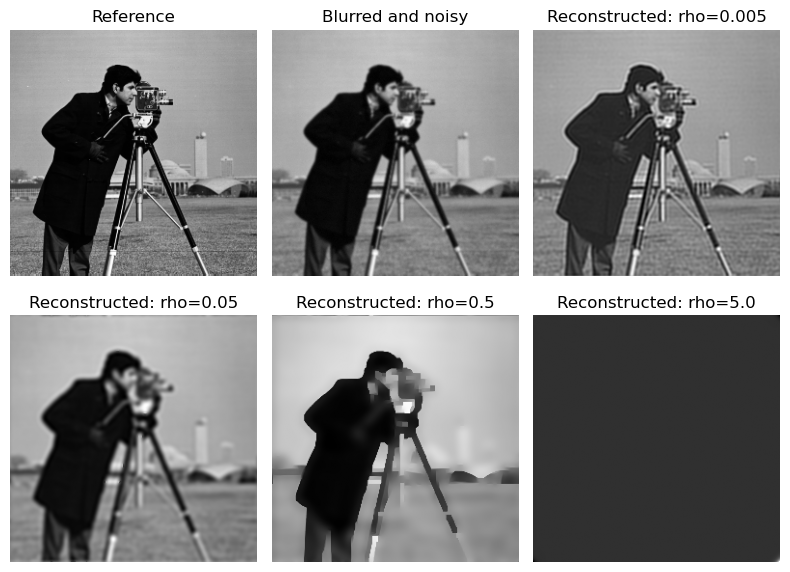

In [55]:
"""Solve using total variation regularisation - tune rho"""

solver = ADMMSolverTV(g, kernel)

plt.figure(figsize=(8, 6))
plt.subplot(2, 3, 1)
plt.imshow(f, cmap="gray")
plt.axis("off")
plt.title("Reference")
plt.subplot(2, 3, 2)
plt.imshow(g, cmap="gray")
plt.axis("off")
plt.title("Blurred and noisy")

for idx, rho in enumerate([0.005, 0.05, 0.5, 5.0]):
    f_hat = solver.solve(
        shrinkage_func=signal_l1,
        params={"threshold": 0.25, "rho": rho},
        max_iter=20,
    )
    plt.subplot(2, 3, 3 + idx)
    plt.title(f"Reconstructed: rho={rho}")
    plt.imshow(f_hat, cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()